In [2]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parents[3]))  # .../SystemSimulation
from demos.ControlledPendulum.src.master_pendulum.components import (
    OpenSimPendulum,
    FEMPendulum,
    PendulumODE, 
    constant_torque,
    ramp_torque,
    zero_torque,
)   

In [3]:
master = FEMPendulum("Master")
master.initialize(0.0)
master._use_gravity = True
master._with_contact = True

model = OpenSimPendulum()
model._use_gravity = master._use_gravity
model._with_contact = master._with_contact

total_inertia = master.inertia
mass = master.mass
length = master._equivalent_length
inertia = total_inertia - mass * (length**2)

model.parameters["Model"]["inertia"] = inertia
model.parameters["Model"]["mass"] = mass
model.parameters["Model"]["length"] = length

model.parameters["InitialConditions"]["q0"] = np.deg2rad(20)
model.parameters["InitialConditions"]["omega0"] = 0
model.parameters["InitialConditions"]["torque0"] = 40

model.initialize(0.0)

In [4]:
# viz = osim.VisualizerUtilities()
# viz.showModel(model.model)

In [5]:
model.parameters["Contact"]

{'with_contact': False,
 'stiffness': 1000000000000.0,
 'dissipation': 0.0,
 'static_friction': 0.0,
 'dynamic_friction': 0.0,
 'viscous_friction': 0.0}

In [6]:
model.parameters["Contact"]["stiffness"] = 1e12
model.parameters["Contact"]["dissipation"] = 0
model.parameters["Contact"]["static_friction"] = 0
model.parameters["Contact"]["dynamic_friction"] = 0
model.parameters["Contact"]["viscous_friction"] = 0

In [7]:
model.initialize(0.0)

In [8]:
t_end = master.sim_params.t_end
dt = master.sim_params.tau
t = 0.0

while t < t_end:
    # 1) Integrate one time step
    model.do_step(t, dt)

    # 2) Advance time
    t += dt

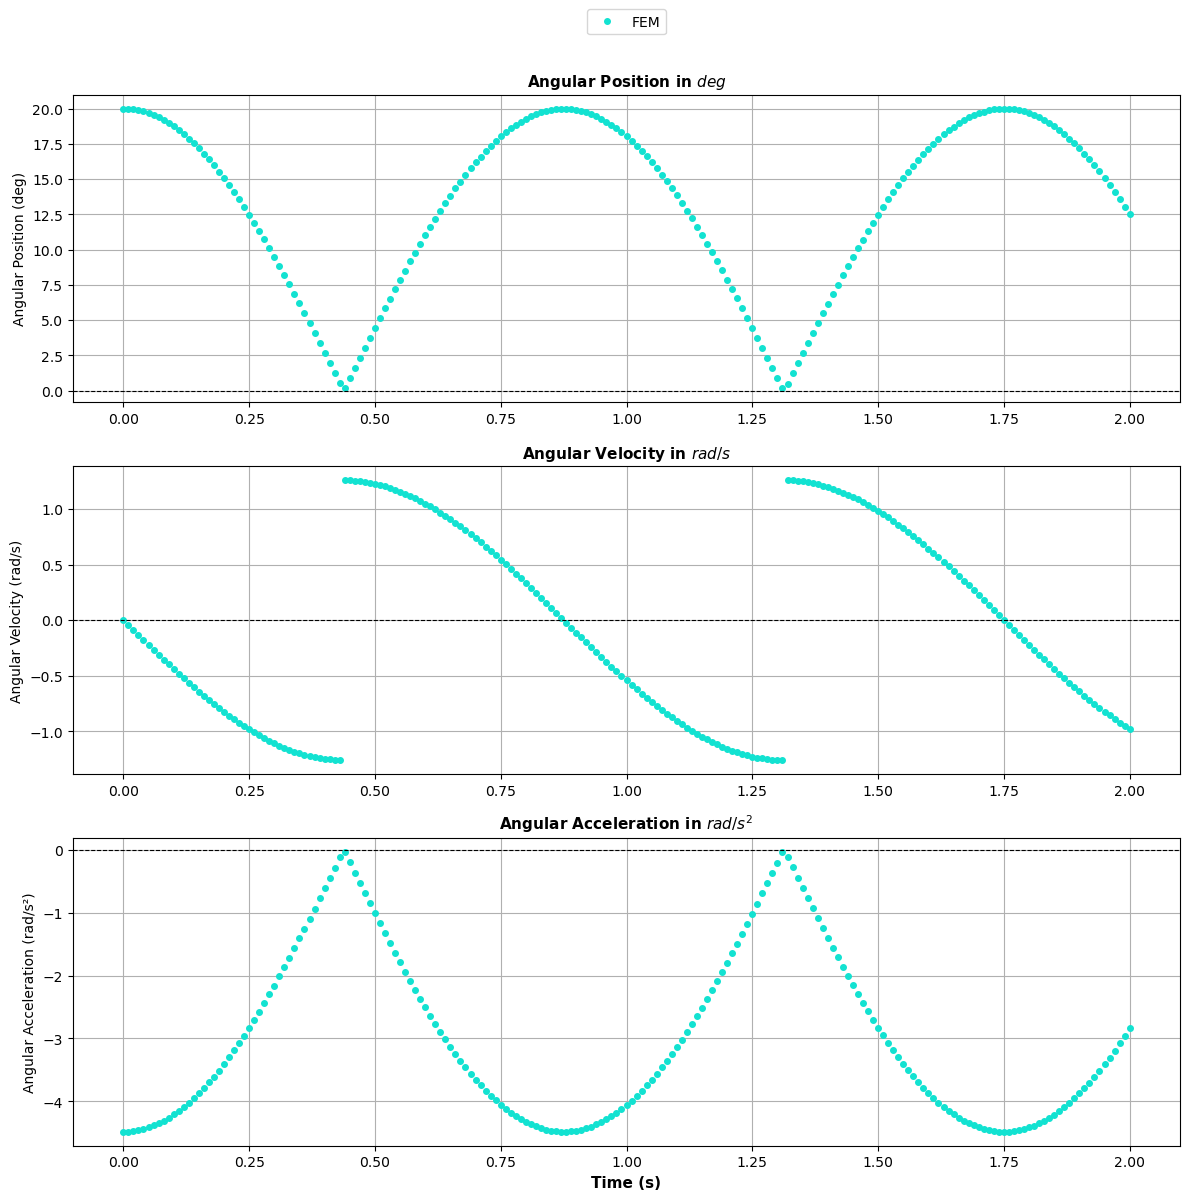

In [9]:
results = model.get_history()

t_vals = results["q"]["time"]
q_fem_vals = results["q"]["values"]
omega_fem_vals = results["omega"]["values"]
alpha_fem_vals = results["alpha"]["values"]

marker_size = 4
fem_style = {
    "color": "#12e2d1",
    "linestyle": "None",
    "marker": "o",
    "markersize": marker_size,
    "linewidth": 3.5,
}
opensim_style = {
    "color": "#f8c20f",
    "linestyle": "None",
    "marker": "s",
    "markersize": marker_size,
    "linewidth": 3.5,
}
eqb_style = {
    "color": "#1d8d43",
    "linestyle": "None",
    "marker": "^",
    "markersize": marker_size,
    "linewidth": 3.5,
}
fontdict = {"fontsize": 11, "fontweight": "bold"}

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_fem_vals), label="FEM", **fem_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which="both")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3, 1, 2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_fem_vals, label="FEM", **fem_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which="both")

plt.subplot(3, 1, 3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_fem_vals, label="FEM", **fem_style)
plt.axhline(0, color="k", linestyle="--", linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which="both")

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
# plt.savefig("../figures/StateSynchronization_driven.svg")
plt.show()

In [9]:
#model.save_model("pendulum_contact.osim")